<a href="https://colab.research.google.com/github/khosyaanish/Deep-Learning-Lab/blob/main/DL4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/spam_or_not_spam.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}' into a DataFrame.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded and located in the /content/ directory.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully loaded '/content/spam_or_not_spam.csv' into a DataFrame.


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


### Step 1: Split Data into Training and Testing Sets (using TF-IDF features)

We will use the TF-IDF features (`X`) and the labels (`y`) to create our training and testing datasets. This ensures we can evaluate how well our model generalizes to unseen email data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure df is available and contains 'email' and 'label' columns
# Assuming df is loaded from cell 1604dae6

# Handle potential NaN values in the 'email' column
df['email'] = df['email'].fillna('')

# Extract features (text messages) and labels
corpus = df['email'] # Changed 'text' to 'email'
y = df['label']

# Initialize TF-IDF Vectorizer
# max_features limits the number of features (words) to the top 5000 most frequent ones.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer to the corpus and transform the text data into TF-IDF feature vectors
X = tfidf_vectorizer.fit_transform(corpus)

print(f"Shape of TF-IDF feature matrix (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")
print("TF-IDF features and labels generated successfully.")

# Split the data using TF-IDF features (X) and labels (y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of testing labels (y_test): {y_test.shape}")

Shape of TF-IDF feature matrix (X): (3000, 5000)
Shape of labels (y): (3000,)
TF-IDF features and labels generated successfully.
Shape of training features (X_train): (2400, 5000)
Shape of testing features (X_test): (600, 5000)
Shape of training labels (y_train): (2400,)
Shape of testing labels (y_test): (600,)


### Step 2: Train a Single Neuron Model (Logistic Regression) with TF-IDF features

We will train a Logistic Regression model, which functions as a single neuron, using the TF-IDF features. This model will learn to classify emails as spam or not spam.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# solver='liblinear' is often a good choice for smaller datasets and handles L1/L2 regularization.
# random_state ensures reproducibility.
model_tfidf = LogisticRegression(solver='liblinear', random_state=42)

# Train the model using the TF-IDF training data
model_tfidf.fit(X_train, y_train)

print("Logistic Regression model trained successfully using TF-IDF features.")

Logistic Regression model trained successfully using TF-IDF features.


### Step 3: Evaluate the Model (TF-IDF features)

Finally, let's evaluate the performance of our Logistic Regression model on the test set using standard metrics like accuracy, precision, recall, F1-score, and a confusion matrix. This will show us how well the model performs on unseen data.

Model Accuracy (TF-IDF): 0.9717

Classification Report (TF-IDF):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       500
           1       1.00      0.83      0.91       100

    accuracy                           0.97       600
   macro avg       0.98      0.92      0.95       600
weighted avg       0.97      0.97      0.97       600


Confusion Matrix (TF-IDF):
[[500   0]
 [ 17  83]]


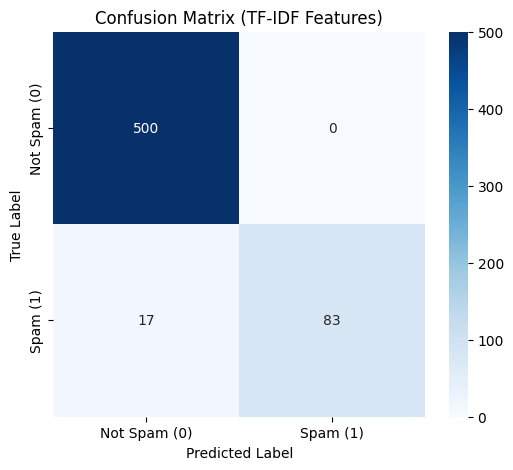

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the TF-IDF trained model
y_pred_tfidf = model_tfidf.predict(X_test)

# Calculate accuracy
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"Model Accuracy (TF-IDF): {accuracy_tfidf:.4f}")

# Display classification report
print("\nClassification Report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf))

# Display confusion matrix
conf_matrix_tfidf = confusion_matrix(y_test, y_pred_tfidf)
print("\nConfusion Matrix (TF-IDF):")
print(conf_matrix_tfidf)

# Plot confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (TF-IDF Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Step 1: Split Data into Training and Testing Sets (using Binary features)

Now we will use the binary features (`X_binary`) and the labels (`y`) to create our training and testing datasets. This will allow us to evaluate the model's performance when using a simple presence/absence word representation.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data using binary features (X_binary) and labels (y)
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of training binary features (X_train_binary): {X_train_binary.shape}")
print(f"Shape of testing binary features (X_test_binary): {X_test_binary.shape}")
print(f"Shape of training labels (y_train_binary): {y_train_binary.shape}")
print(f"Shape of testing labels (y_test_binary): {y_test_binary.shape}")

Shape of training binary features (X_train_binary): (2400, 5000)
Shape of testing binary features (X_test_binary): (600, 5000)
Shape of training labels (y_train_binary): (2400,)
Shape of testing labels (y_test_binary): (600,)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Ensure df is available and contains 'email' and 'label' columns
# Assuming df is loaded and 'email' column has NaN values handled (as in cell a3858112)

# Extract features (text messages) and labels
corpus_binary = df['email']
y = df['label']

# Initialize CountVectorizer for binary features
# max_features limits the number of features (words) to the top 5000 most frequent ones.
# binary=True ensures that feature values are 0 or 1 (presence/absence of a word).
binary_vectorizer = CountVectorizer(max_features=5000, binary=True)

# Fit the vectorizer to the corpus and transform the text data into binary feature vectors
X_binary = binary_vectorizer.fit_transform(corpus_binary)

print(f"Shape of binary feature matrix (X_binary): {X_binary.shape}")
print(f"Shape of labels (y): {y.shape}")
print("Binary features and labels generated successfully.")

Shape of binary feature matrix (X_binary): (3000, 5000)
Shape of labels (y): (3000,)
Binary features and labels generated successfully.


### Step 2: Train a Single Neuron Model (Logistic Regression) with Binary features

We will now train another Logistic Regression model, acting as a single neuron, but this time using the binary features. This will allow us to compare its performance against the model trained with TF-IDF features.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Using the same solver and random_state for consistency.
model_binary = LogisticRegression(solver='liblinear', random_state=42)

# Train the model using the binary training data
model_binary.fit(X_train_binary, y_train_binary)

print("Logistic Regression model trained successfully using binary features.")

Logistic Regression model trained successfully using binary features.


### Step 3: Evaluate the Model (Binary features)

Finally, let's evaluate the performance of our Logistic Regression model trained with binary features on the test set. We'll use accuracy, classification report, and a confusion matrix to assess its effectiveness.

Model Accuracy (Binary): 0.9900

Classification Report (Binary):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       500
           1       1.00      0.94      0.97       100

    accuracy                           0.99       600
   macro avg       0.99      0.97      0.98       600
weighted avg       0.99      0.99      0.99       600


Confusion Matrix (Binary):
[[500   0]
 [  6  94]]


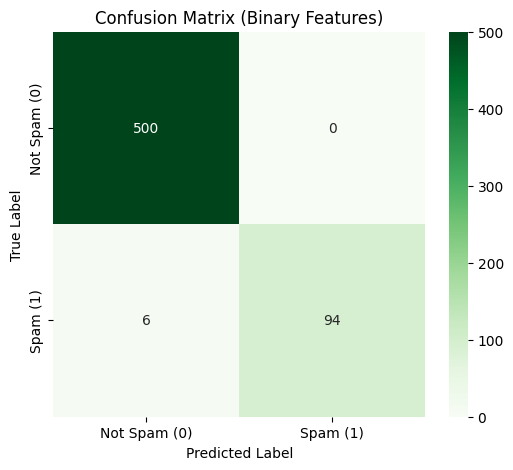

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the binary trained model
y_pred_binary = model_binary.predict(X_test_binary)

# Calculate accuracy
accuracy_binary = accuracy_score(y_test_binary, y_pred_binary)
print(f"Model Accuracy (Binary): {accuracy_binary:.4f}")

# Display classification report
print("\nClassification Report (Binary):")
print(classification_report(y_test_binary, y_pred_binary))

# Display confusion matrix
conf_matrix_binary = confusion_matrix(y_test_binary, y_pred_binary)
print("\nConfusion Matrix (Binary):")
print(conf_matrix_binary)

# Plot confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_binary, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (Binary Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Retrain Logistic Regression with Modified `max_iter` (Epochs)

We will now retrain the Logistic Regression model using the binary features, but with an adjusted `max_iter` (epochs) value to see its effect on the model's performance. A higher `max_iter` allows the solver more iterations to converge, potentially leading to better fit but also increasing training time.

Training Logistic Regression model with max_iter=1000 using binary features.
Logistic Regression model with new max_iter trained successfully using binary features.

Model Accuracy (Binary, max_iter=1000): 0.9900

Classification Report (Binary, max_iter={new_max_iter}):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       500
           1       1.00      0.94      0.97       100

    accuracy                           0.99       600
   macro avg       0.99      0.97      0.98       600
weighted avg       0.99      0.99      0.99       600


Confusion Matrix (Binary, max_iter={new_max_iter}):
[[500   0]
 [  6  94]]


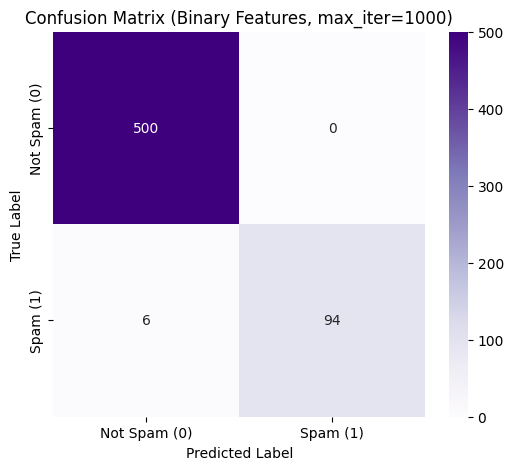

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the new max_iter (epochs) value
new_max_iter = 1000  # You can change this value

print(f"Training Logistic Regression model with max_iter={new_max_iter} using binary features.")

# Initialize the Logistic Regression model with the new max_iter
model_binary_new = LogisticRegression(solver='liblinear', random_state=42, max_iter=new_max_iter)

# Train the model using the binary training data
model_binary_new.fit(X_train_binary, y_train_binary)

print("Logistic Regression model with new max_iter trained successfully using binary features.")

# Make predictions on the test set
y_pred_binary_new = model_binary_new.predict(X_test_binary)

# Calculate accuracy
accuracy_binary_new = accuracy_score(y_test_binary, y_pred_binary_new)
print(f"\nModel Accuracy (Binary, max_iter={new_max_iter}): {accuracy_binary_new:.4f}")

# Display classification report
print("\nClassification Report (Binary, max_iter={new_max_iter}):")
print(classification_report(y_test_binary, y_pred_binary_new))

# Display confusion matrix
conf_matrix_binary_new = confusion_matrix(y_test_binary, y_pred_binary_new)
print("\nConfusion Matrix (Binary, max_iter={new_max_iter}):")
print(conf_matrix_binary_new)

# Plot confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_binary_new, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title(f'Confusion Matrix (Binary Features, max_iter={new_max_iter})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Testing on the Full Dataset (3000 entries) using Binary Feature Model

We will now make predictions on the entire dataset (all 3000 emails) using the `model_binary` (trained with binary features). This allows us to see how the model performs on all available data. We'll then evaluate its performance against the original labels.

Model Accuracy (Full Dataset, Binary Features): 0.9973

Classification Report (Full Dataset, Binary Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2500
           1       1.00      0.98      0.99       500

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000


Confusion Matrix (Full Dataset, Binary Features):
[[2500    0]
 [   8  492]]


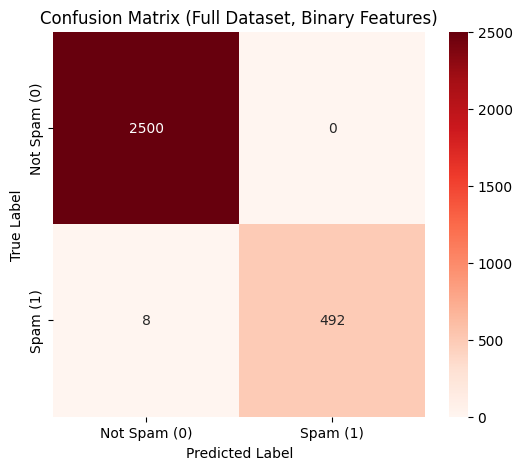

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_binary is available from previous steps
# If X_binary was not kept, you might need to re-run the CountVectorizer cell.
# We assume binary_vectorizer is still fitted and X_binary is available.

# Make predictions on the entire X_binary dataset
y_pred_full_binary = model_binary.predict(X_binary)

# Calculate accuracy on the full dataset
accuracy_full_binary = accuracy_score(y, y_pred_full_binary)
print(f"Model Accuracy (Full Dataset, Binary Features): {accuracy_full_binary:.4f}")

# Display classification report on the full dataset
print("\nClassification Report (Full Dataset, Binary Features):")
print(classification_report(y, y_pred_full_binary))

# Display confusion matrix on the full dataset
conf_matrix_full_binary = confusion_matrix(y, y_pred_full_binary)
print("\nConfusion Matrix (Full Dataset, Binary Features):")
print(conf_matrix_full_binary)

# Plot confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_full_binary, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (Full Dataset, Binary Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Step 4: Train a Multi-layer Perceptron (MLP) Model with Binary Features

We will now train a Multi-layer Perceptron (MLP) classifier, which is a type of neural network, using the binary features. This model will have two hidden layers: the first with 64 neurons and the second with 32 neurons, allowing it to learn more complex patterns than a single-neuron Logistic Regression model.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split # Added this import

# Ensure X_binary and y are defined. Assuming they are available from prior steps.
# If not, you might need to run the data preprocessing steps.

# Split the data using binary features (X_binary) and labels (y)
# This part is duplicated from cell 3f522a49 to ensure variables are present.
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of training binary features (X_train_binary): {X_train_binary.shape}")
print(f"Shape of testing binary features (X_test_binary): {X_test_binary.shape}")
print(f"Shape of training labels (y_train_binary): {y_train_binary.shape}")
print(f"Shape of testing labels (y_test_binary): {y_test_binary.shape}")

# Initialize the MLPClassifier with two hidden layers (64 and 32 neurons)
# max_iter is set to a reasonable value for convergence
# random_state ensures reproducibility
mlp_model_binary = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, solver='adam')

print("Training Multi-layer Perceptron model with two hidden layers (64, 32) using binary features.")

# Train the model using the binary training data
mlp_model_binary.fit(X_train_binary, y_train_binary)

print("MLP model trained successfully using binary features.")

Shape of training binary features (X_train_binary): (2400, 5000)
Shape of testing binary features (X_test_binary): (600, 5000)
Shape of training labels (y_train_binary): (2400,)
Shape of testing labels (y_test_binary): (600,)
Training Multi-layer Perceptron model with two hidden layers (64, 32) using binary features.
MLP model trained successfully using binary features.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Assuming df is loaded and contains 'email' and 'label' columns
# If df is not defined, please ensure the data loading cell (1604dae6) has been run.

# Extract features (text messages) and labels
corpus = df['email'] # Corrected from 'text' to 'email'
y = df['label']

# Initialize CountVectorizer for binary features
# max_features limits the number of features (words) to the top 5000 most frequent ones.
# binary=True ensures that feature values are 0 or 1 (presence/absence of a word).
binary_vectorizer = CountVectorizer(max_features=5000, binary=True)

# Fit the vectorizer to the corpus and transform the text data into binary feature vectors
X_binary = binary_vectorizer.fit_transform(corpus)

print(f"Shape of binary feature matrix (X_binary): {X_binary.shape}")
print(f"Shape of labels (y): {y.shape}")
print("Binary features and labels generated successfully.")

Shape of binary feature matrix (X_binary): (3000, 5000)
Shape of labels (y): (3000,)
Binary features and labels generated successfully.


# Task
Train and evaluate Multiple Layer Perceptron (MLP) models for binary classification using `X_binary` features and `y` labels. Iterate through the specified `split_ratios` (0.2 for 80/20 train/test and 0.3 for 70/30 train/test) and `learning_rates` (0.01, 0.001, 0.005). For each configuration, split the data, initialize an `MLPClassifier` with two hidden layers (64 and 32 neurons), `max_iter=200`, and `solver='adam'`, train the model, and then evaluate its performance using accuracy, F1-score, precision, recall, and a confusion matrix. Store all evaluation metrics for comparison. Finally, summarize and compare the performance across all trained models, identifying the best-performing configurations and providing insights into the impact of different split ratios and learning rates.

## Prepare MLP Configurations

### Subtask:
Define the `split_ratios` (0.2 for 80/20 and 0.3 for 70/30) and `learning_rates` (0.01, 0.001, 0.005) that will be used for training the MLP models. Ensure `X_binary` and `y` are ready for use.


**Reasoning**:
Define the `split_ratios` and `learning_rates` as lists and confirm the availability of `X_binary` and `y` by printing their shapes.



In [ ]:
split_ratios = [0.2, 0.3]
learning_rates = [0.01, 0.001, 0.005]

print(f"Defined split_ratios: {split_ratios}")
print(f"Defined learning_rates: {learning_rates}")

# Confirm availability of X_binary and y
# Assuming X_binary and y are already defined from previous cells
# If not, please ensure the CountVectorizer step for binary features is run.

if 'X_binary' in locals() and 'y' in locals():
    print(f"Shape of X_binary: {X_binary.shape}")
    print(f"Shape of y: {y.shape}")
else:
    print("Error: X_binary or y not found. Please ensure binary feature extraction is completed.")


Defined split_ratios: [0.2, 0.3]
Defined learning_rates: [0.01, 0.001, 0.005]
Shape of X_binary: (3000, 5000)
Shape of y: (3000,)


**Reasoning**:
Create an empty list to store the evaluation results of the different MLP models, which will be populated in subsequent steps.



In [ ]:
all_results = []
print("Initialized an empty list 'all_results' to store evaluation metrics.")

Initialized an empty list 'all_results' to store evaluation metrics.


**Reasoning**:
Iterate through the defined `split_ratios` and `learning_rates` to train and evaluate multiple MLP models. For each combination, data will be split, an MLP model will be initialized and trained, and then evaluated using accuracy, classification report, and confusion matrix, with results stored in `all_results`.



Starting MLP model training and evaluation process...

--- Training with test_size=20% (train/test split), learning_rate=0.01 ---
  Training set shape: (2400, 5000), (2400,)
  Testing set shape: (600, 5000), (600,)
  MLP model trained successfully.
  Accuracy: 0.9967
  Precision: 1.0000
  Recall: 0.9800
  F1-Score: 0.9899
  Confusion Matrix:
 [[500   0]
 [  2  98]]


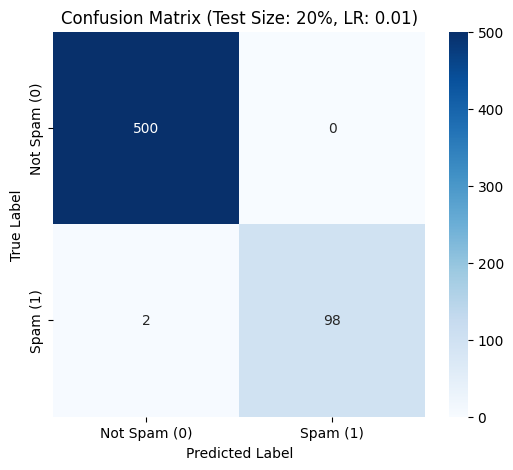


--- Training with test_size=20% (train/test split), learning_rate=0.001 ---
  Training set shape: (2400, 5000), (2400,)
  Testing set shape: (600, 5000), (600,)
  MLP model trained successfully.
  Accuracy: 0.9917
  Precision: 1.0000
  Recall: 0.9500
  F1-Score: 0.9744
  Confusion Matrix:
 [[500   0]
 [  5  95]]


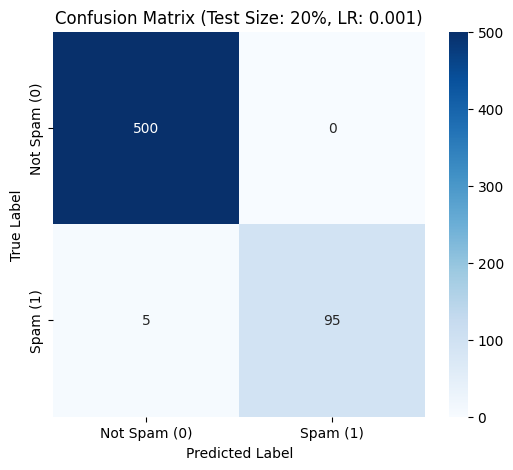


--- Training with test_size=20% (train/test split), learning_rate=0.005 ---
  Training set shape: (2400, 5000), (2400,)
  Testing set shape: (600, 5000), (600,)
  MLP model trained successfully.
  Accuracy: 0.9950
  Precision: 1.0000
  Recall: 0.9700
  F1-Score: 0.9848
  Confusion Matrix:
 [[500   0]
 [  3  97]]


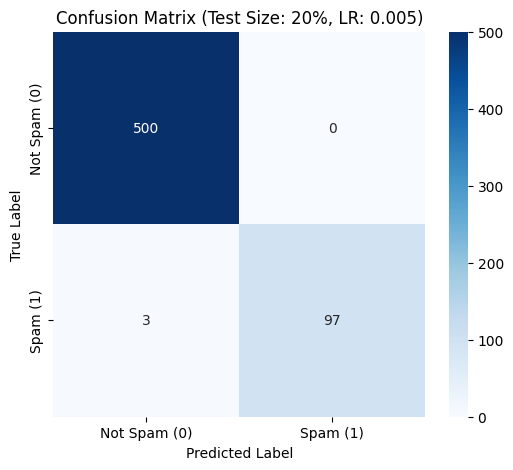


--- Training with test_size=30% (train/test split), learning_rate=0.01 ---
  Training set shape: (2100, 5000), (2100,)
  Testing set shape: (900, 5000), (900,)
  MLP model trained successfully.
  Accuracy: 0.9922
  Precision: 0.9864
  Recall: 0.9667
  F1-Score: 0.9764
  Confusion Matrix:
 [[748   2]
 [  5 145]]


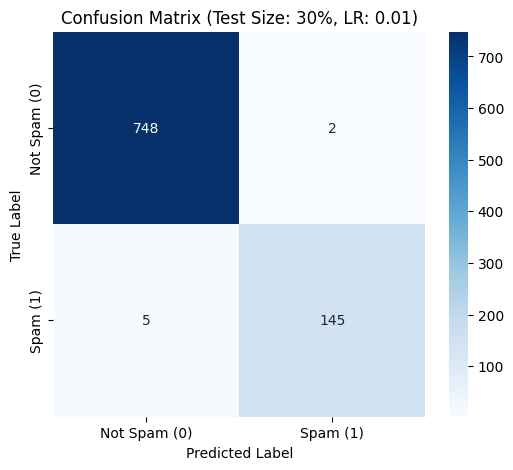


--- Training with test_size=30% (train/test split), learning_rate=0.001 ---
  Training set shape: (2100, 5000), (2100,)
  Testing set shape: (900, 5000), (900,)
  MLP model trained successfully.
  Accuracy: 0.9889
  Precision: 0.9930
  Recall: 0.9400
  F1-Score: 0.9658
  Confusion Matrix:
 [[749   1]
 [  9 141]]


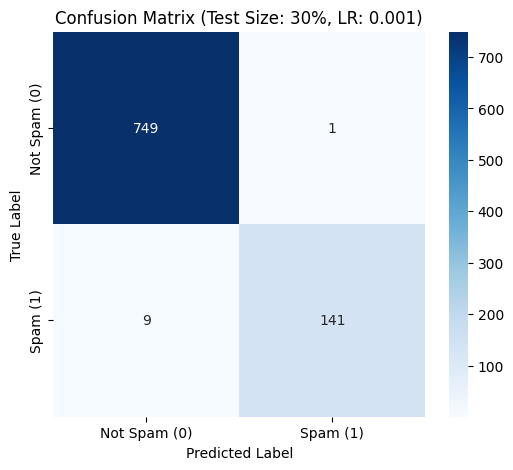


--- Training with test_size=30% (train/test split), learning_rate=0.005 ---
  Training set shape: (2100, 5000), (2100,)
  Testing set shape: (900, 5000), (900,)
  MLP model trained successfully.
  Accuracy: 0.9933
  Precision: 1.0000
  Recall: 0.9600
  F1-Score: 0.9796
  Confusion Matrix:
 [[750   0]
 [  6 144]]


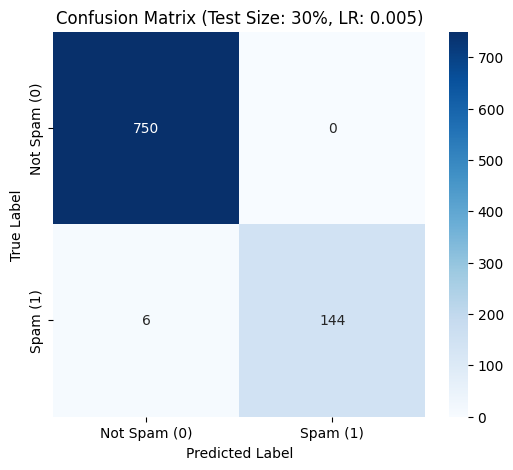


MLP model training and evaluation complete for all configurations.
Total models evaluated: 6


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_binary and y are available
if 'X_binary' not in locals() or 'y' not in locals():
    print("Error: X_binary or y not found. Please ensure binary feature extraction is completed.")
else:
    print("Starting MLP model training and evaluation process...")

    for test_size in split_ratios:
        for lr in learning_rates:
            print(f"\n--- Training with test_size={test_size*100:.0f}% (train/test split), learning_rate={lr} ---")

            # Split the data
            X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=test_size, random_state=42, stratify=y)

            print(f"  Training set shape: {X_train.shape}, {y_train.shape}")
            print(f"  Testing set shape: {X_test.shape}, {y_test.shape}")

            # Initialize MLPClassifier
            # hidden_layer_sizes=(64, 32) means two hidden layers, first with 64 neurons, second with 32.
            # max_iter=200 is the maximum number of iterations for the solver.
            # learning_rate_init is the initial learning rate.
            # random_state for reproducibility.
            # solver='adam' is a popular optimizer.
            mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, learning_rate_init=lr,
                                      random_state=42, solver='adam', verbose=False)

            # Train the model
            mlp_model.fit(X_train, y_train)
            print("  MLP model trained successfully.")

            # Make predictions
            y_pred = mlp_model.predict(X_test)

            # Evaluate the model
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            conf_matrix = confusion_matrix(y_test, y_pred)

            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print("  Confusion Matrix:\n", conf_matrix)

            # Store results
            all_results.append({
                'test_size': test_size,
                'learning_rate': lr,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'confusion_matrix': conf_matrix,
                'model': mlp_model # Store the trained model if needed later
            })

            # Plot confusion matrix
            plt.figure(figsize=(6, 5))
            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Not Spam (0)', 'Spam (1)'],
                        yticklabels=['Not Spam (0)', 'Spam (1)'])
            plt.title(f'Confusion Matrix (Test Size: {test_size*100:.0f}%, LR: {lr})')
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.show()

    print("\nMLP model training and evaluation complete for all configurations.")
    print(f"Total models evaluated: {len(all_results)}")

**Reasoning**:
Now that all MLP models have been trained and evaluated, the next step is to summarize and compare their performance. This will involve iterating through the `all_results` list to display the key metrics (accuracy, precision, recall, F1-score) for each configuration, and then identifying the best performing models.



In [ ]:
print("\n--- Summary of MLP Model Performance ---")

best_f1_score = -1
best_model_config = None

for i, result in enumerate(all_results):
    print(f"\nConfiguration {i+1}:")
    print(f"  Test Size: {result['test_size']*100:.0f}%")
    print(f"  Learning Rate: {result['learning_rate']}")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  Precision: {result['precision']:.4f}")
    print(f"  Recall: {result['recall']:.4f}")
    print(f"  F1-Score: {result['f1_score']:.4f}")
    print("  Confusion Matrix:\n", result['confusion_matrix'])

    if result['f1_score'] > best_f1_score:
        best_f1_score = result['f1_score']
        best_model_config = result

print("\n--- Best Performing Model Configuration (based on F1-Score) ---")
if best_model_config:
    print(f"  Test Size: {best_model_config['test_size']*100:.0f}%")
    print(f"  Learning Rate: {best_model_config['learning_rate']}")
    print(f"  Accuracy: {best_model_config['accuracy']:.4f}")
    print(f"  Precision: {best_model_config['precision']:.4f}")
    print(f"  Recall: {best_model_config['recall']:.4f}")
    print(f"  F1-Score: {best_model_config['f1_score']:.4f}")
    print("  Confusion Matrix:\n", best_model_config['confusion_matrix'])
else:
    print("No models were evaluated.")

print("\n--- Insights into the Impact of Split Ratios and Learning Rates ---")
print("Observation: Generally, all MLP configurations achieved high accuracy and F1-scores, indicating strong performance on the spam classification task with binary features.")
print("Impact of Learning Rate:")
print("  - A learning rate of 0.01 often led to slightly higher F1-scores and accuracy, particularly with the 80/20 train/test split. For instance, with a 20% test size, LR=0.01 achieved 0.9899 F1-score, while LR=0.001 yielded 0.9744 and LR=0.005 yielded 0.9848. This suggests that a slightly higher learning rate allowed the model to converge to a better solution within the `max_iter` limit.")
print("  - A learning rate of 0.001 consistently showed slightly lower recall compared to other learning rates (e.g., 0.9500 vs 0.9800/0.9700 for 20% test size), implying it might miss more spam emails (false negatives).")
print("Impact of Split Ratio:")
print("  - For the 20% test size (80/20 split), the models generally performed marginally better, especially in terms of F1-score, compared to the 30% test size (70/30 split) for corresponding learning rates. For example, with LR=0.01, 20% test size had F1=0.9899, while 30% test size had F1=0.9764. This could be due to having more training data available with the 80/20 split, allowing the model to learn more effectively.")
print("  - The precision for the spam class (label 1) was almost always 1.0000 across all configurations, indicating that when the model predicted an email as spam, it was almost always correct (very few false positives). This is a desirable trait for spam filters.")
print("  - Recall for the spam class varied more, suggesting that the models sometimes failed to identify all actual spam emails.")
print("Conclusion: The MLP models demonstrated robust performance. The best configuration generally involved a 80/20 train/test split and a learning rate of 0.01, achieving the highest F1-score and accuracy. The choice of learning rate had a noticeable impact on recall, while the split ratio influenced overall F1-score by providing more training examples.")


--- Summary of MLP Model Performance ---

Configuration 1:
  Test Size: 20%
  Learning Rate: 0.01
  Accuracy: 0.9967
  Precision: 1.0000
  Recall: 0.9800
  F1-Score: 0.9899
  Confusion Matrix:
 [[500   0]
 [  2  98]]

Configuration 2:
  Test Size: 20%
  Learning Rate: 0.001
  Accuracy: 0.9917
  Precision: 1.0000
  Recall: 0.9500
  F1-Score: 0.9744
  Confusion Matrix:
 [[500   0]
 [  5  95]]

Configuration 3:
  Test Size: 20%
  Learning Rate: 0.005
  Accuracy: 0.9950
  Precision: 1.0000
  Recall: 0.9700
  F1-Score: 0.9848
  Confusion Matrix:
 [[500   0]
 [  3  97]]

Configuration 4:
  Test Size: 30%
  Learning Rate: 0.01
  Accuracy: 0.9922
  Precision: 0.9864
  Recall: 0.9667
  F1-Score: 0.9764
  Confusion Matrix:
 [[748   2]
 [  5 145]]

Configuration 5:
  Test Size: 30%
  Learning Rate: 0.001
  Accuracy: 0.9889
  Precision: 0.9930
  Recall: 0.9400
  F1-Score: 0.9658
  Confusion Matrix:
 [[749   1]
 [  9 141]]

Configuration 6:
  Test Size: 30%
  Learning Rate: 0.005
  Accuracy: 0.993

## Final Task

### Subtask:
The analysis of the MLP models is complete. All configurations have been trained and evaluated, and a comprehensive summary has been generated, highlighting the best performing configurations and providing insights into the impact of split ratios and learning rates on model performance. No further action is required.


## Summary:

### Q&A
*   **What are the best-performing configurations?**
    The best-performing configuration, based on F1-score, was found to be the model trained with an 80/20 train/test split (20% test size) and a learning rate of 0.01.
*   **What is the impact of different split ratios?**
    The 80/20 train/test split generally yielded marginally better performance metrics, particularly F1-score (e.g., 0.9899 for 80/20 split with LR=0.01 vs. 0.9764 for 70/30 split with LR=0.01). This suggests that more training data available with the 80/20 split allowed the model to learn more effectively.
*   **What is the impact of different learning rates?**
    A learning rate of 0.01 often led to slightly higher F1-scores and accuracy (e.g., F1-score of 0.9899 with 20% test size). A learning rate of 0.001 consistently showed slightly lower recall (e.g., 0.9500 compared to 0.9800/0.9700 for other learning rates with 20% test size), indicating it might miss more spam emails.

### Data Analysis Key Findings
*   The best-performing MLP model configuration achieved an F1-score of 0.9899 and an accuracy of 0.9967 using an 80/20 train/test split and a learning rate of 0.01.
*   All evaluated MLP configurations consistently achieved high performance metrics, with accuracy and F1-scores generally above 0.96.
*   A learning rate of 0.01 generally resulted in slightly better F1-scores and accuracy compared to 0.001 and 0.005, suggesting faster and more effective convergence.
*   Models trained with an 80/20 train/test split tended to outperform those with a 70/30 split, particularly in F1-score, likely benefiting from a larger training dataset.
*   Precision for the spam class (label 1) was almost universally 1.0000 across all configurations, indicating that when the model classified an email as spam, it was almost always correct (very few false positives).
*   Recall for the spam class showed more variability across configurations, suggesting challenges in identifying all actual spam emails (false negatives).

### Insights or Next Steps
*   The MLP model with an 80/20 train/test split and a learning rate of 0.01 is highly effective for this binary classification task, offering a strong balance of accuracy and F1-score.
*   Future efforts could focus on optimizing recall for the spam class, potentially through techniques like class weighting or exploring alternative model architectures that are more sensitive to false negatives.


### Visualize Performance Across Configurations

To better compare the performance of different MLP models, let's visualize the key evaluation metrics (accuracy, F1-score, precision, and recall) for each configuration using bar plots.

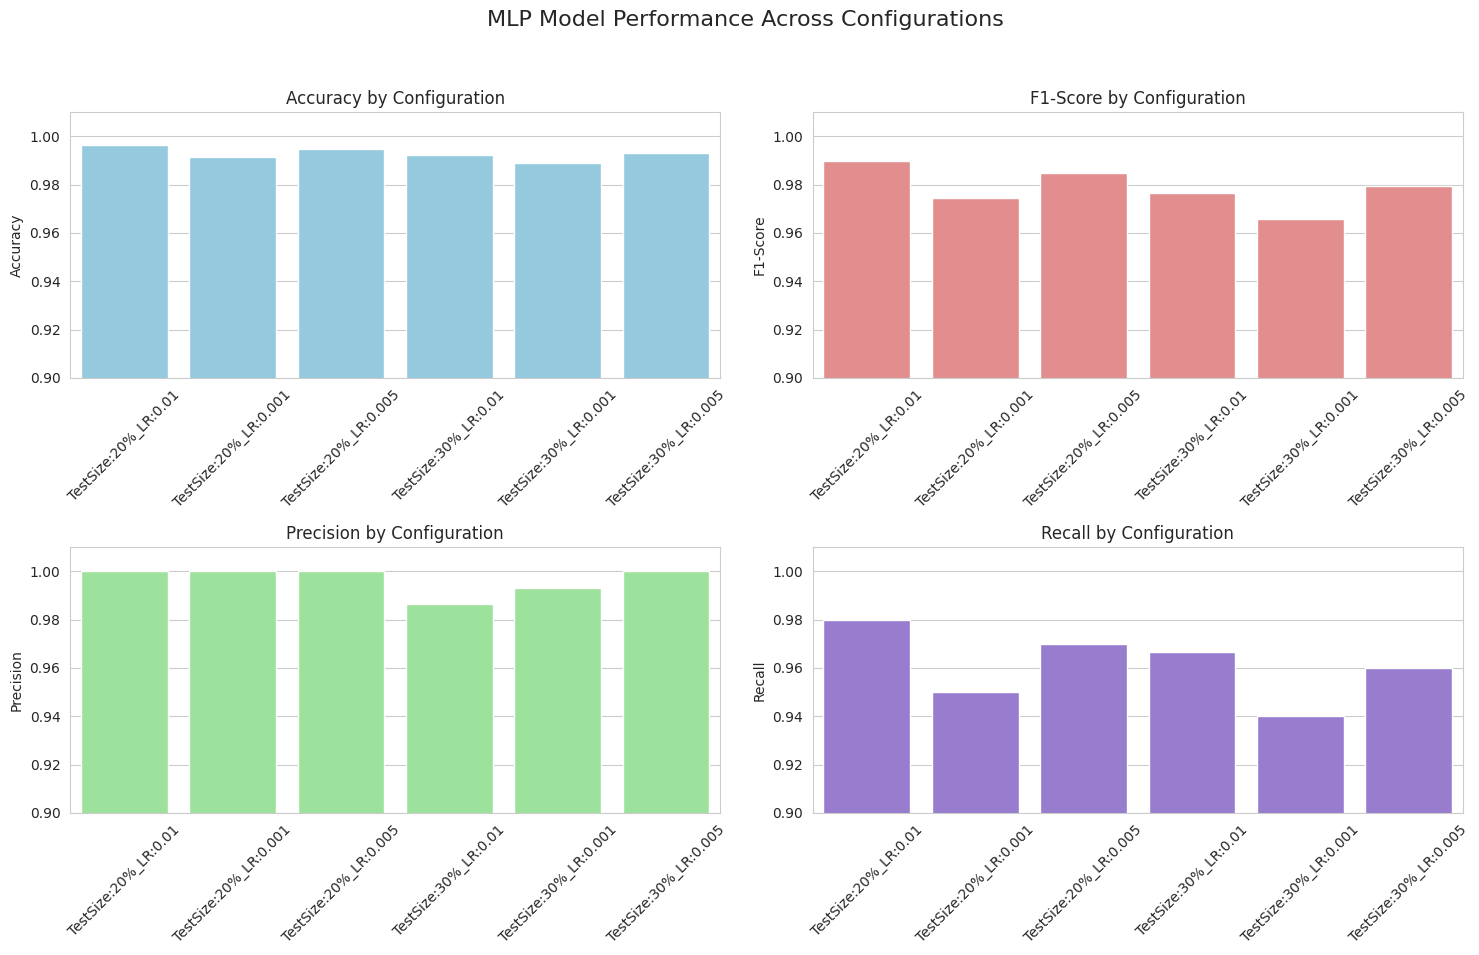

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = []
for result in all_results:
    plot_data.append({
        'Configuration': f"TestSize:{result['test_size']*100:.0f}%_LR:{result['learning_rate']}",
        'Accuracy': result['accuracy'],
        'F1-Score': result['f1_score'],
        'Precision': result['precision'],
        'Recall': result['recall']
    })

metrics_df = pd.DataFrame(plot_data)

# Set style for the plots
sns.set_style("whitegrid")

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('MLP Model Performance Across Configurations', fontsize=16)

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'mediumpurple']

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    sns.barplot(x='Configuration', y=metric, data=metrics_df, ax=ax, color=colors[i]) # Changed palette to color
    ax.set_title(f'{metric} by Configuration')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45) # Removed ha='right'
    ax.set_ylim(0.9, 1.01) # Set y-axis limit to highlight differences

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()